# House Price Prediction — Real Dataset (Juhi Bhojani, Kaggle)

Trains on the **real** `house_prices.csv` (Indian real-estate listings, 187,531 raw rows, 21 raw columns). No synthetic data is used anywhere.

Pipeline: load real data -> inspect real schema -> EDA on real data -> clean/parse messy real fields -> train/test split -> **outlier removal (price-per-sqft based, thresholds from TRAIN only)** -> **Top-50 + 'other' location grouping (from TRAIN only)** -> train **two** regression models -> evaluate & compare both -> select a winner -> save `house_price.pkl` (compressed, <50MB) and `locations.json`.

In [1]:
import sys
sys.path.append('../src')

import json
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from data_loader import load_real_dataset, inspect_schema
from feature_engineering import (
    clean_real_dataset,
    compute_price_per_sqft_bounds,
    filter_price_per_sqft_outliers,
    compute_top_n_locations,
    apply_location_grouping,
    OTHER_LOCATION_LABEL,
)
from preprocessing import PreprocessConfig, split_features_target, build_preprocessor


## 1. Load and inspect the real dataset

In [2]:
df_raw = load_real_dataset()
schema = inspect_schema(df_raw)
print('Shape:', schema['shape'])
df_raw.head()

Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
for col, dtype in schema['dtypes'].items():
    print(f"{col:25s} {dtype:10s} missing={schema['missing_values'][col]:>7} unique={schema['n_unique'][col]}")

Index                     int64      missing=      0 unique=187531
Title                     str        missing=      0 unique=32446
Description               str        missing=   3023 unique=65634
Amount(in rupees)         str        missing=      0 unique=1561
Price (in rupees)         float64    missing=  17665 unique=10958
location                  str        missing=      0 unique=81
Carpet Area               str        missing=  80673 unique=2758
Status                    str        missing=    615 unique=1
Floor                     str        missing=   7077 unique=947
Transaction               str        missing=     83 unique=4
Furnishing                str        missing=   2897 unique=3
facing                    str        missing=  70233 unique=8
overlooking               str        missing=  81436 unique=19
Society                   str        missing= 109678 unique=10376
Bathroom                  str        missing=    828 unique=11
Balcony                   str        m

## 2. EDA on the real raw data

Exploratory plots computed directly from the real 187,531-row file, before any cleaning, so we can see what we're dealing with.

### EDA Plot 1 — Missing values per raw column

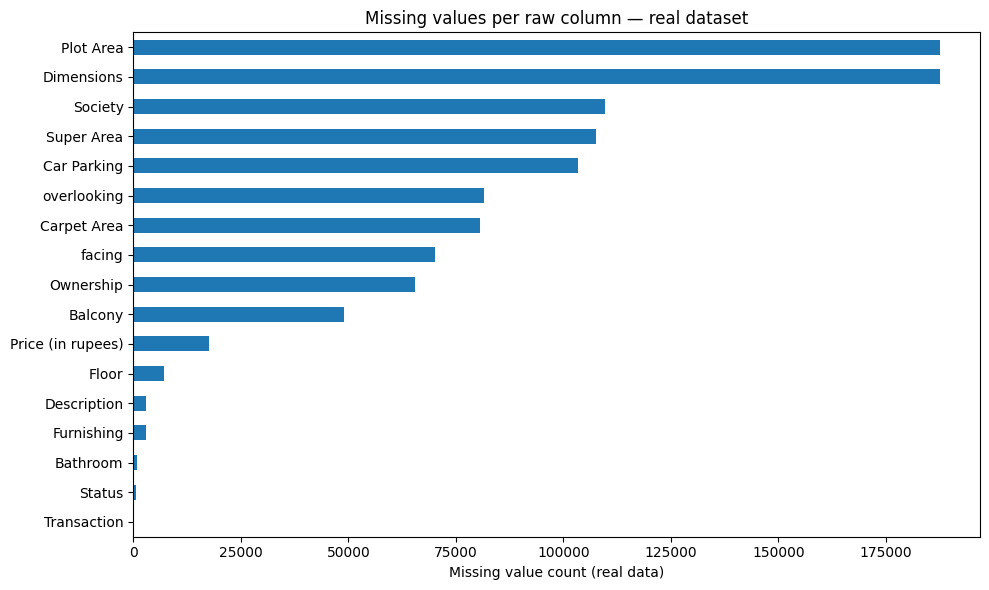

In [4]:
missing = df_raw.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, 6))
missing.plot(kind='barh')
plt.xlabel('Missing value count (real data)')
plt.title('Missing values per raw column — real dataset')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### EDA Plot 2 — Real price distribution (parsed from `Amount(in rupees)`)

Parsed here directly (not via the full cleaning function yet) purely for an early look at the target's real shape.

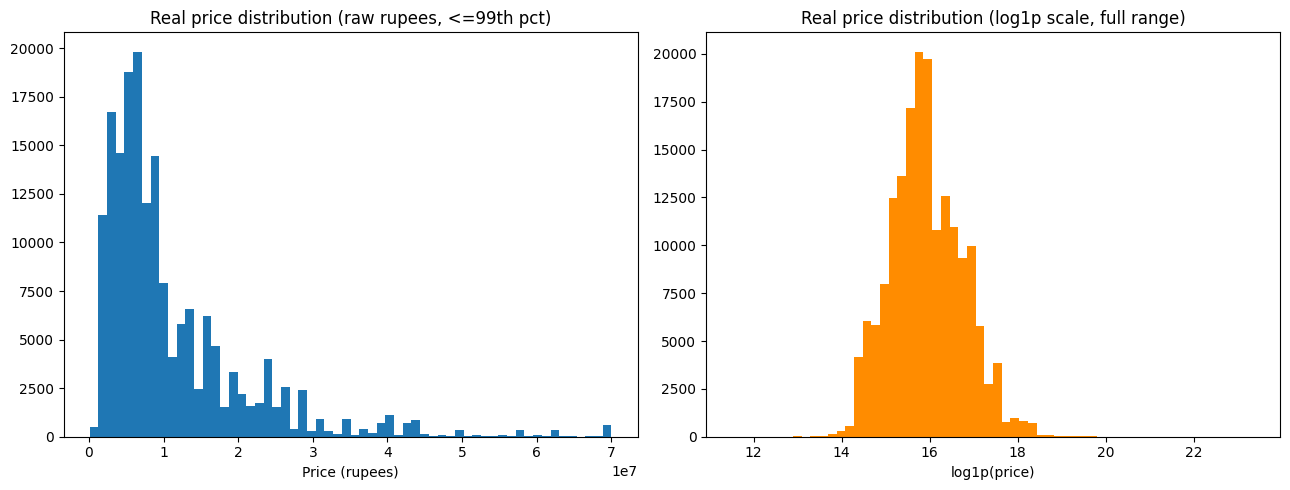

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: Amount(in rupees), dtype: float64


In [5]:
from feature_engineering import parse_amount_to_rupees

price_preview = parse_amount_to_rupees(df_raw['Amount(in rupees)']).dropna()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(price_preview[price_preview <= price_preview.quantile(0.99)], bins=60)
axes[0].set_title('Real price distribution (raw rupees, <=99th pct)')
axes[0].set_xlabel('Price (rupees)')

axes[1].hist(np.log1p(price_preview), bins=60, color='darkorange')
axes[1].set_title('Real price distribution (log1p scale, full range)')
axes[1].set_xlabel('log1p(price)')
plt.tight_layout()
plt.show()

print(price_preview.describe())

### EDA Plot 3 — Real average price by top 10 locations

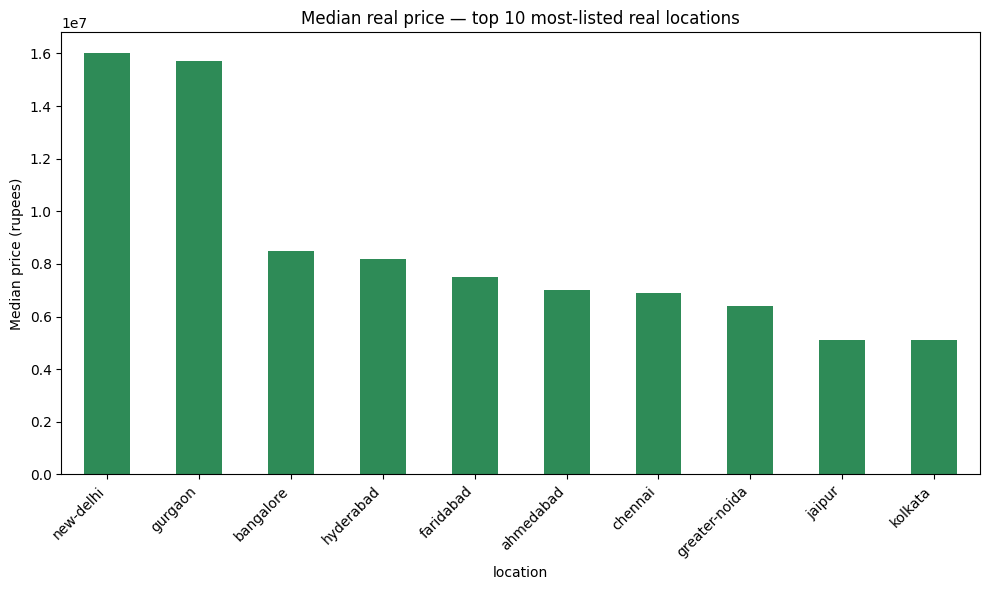

In [6]:
loc_price = pd.DataFrame({'location': df_raw['location'], 'price': price_preview})
top_locations_preview = loc_price['location'].value_counts().head(10).index
avg_by_loc = (loc_price[loc_price['location'].isin(top_locations_preview)]
              .groupby('location')['price'].median()
              .sort_values(ascending=False))

plt.figure(figsize=(10, 6))
avg_by_loc.plot(kind='bar', color='seagreen')
plt.ylabel('Median price (rupees)')
plt.title('Median real price — top 10 most-listed real locations')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### EDA Plot 4 — Real area vs. real price

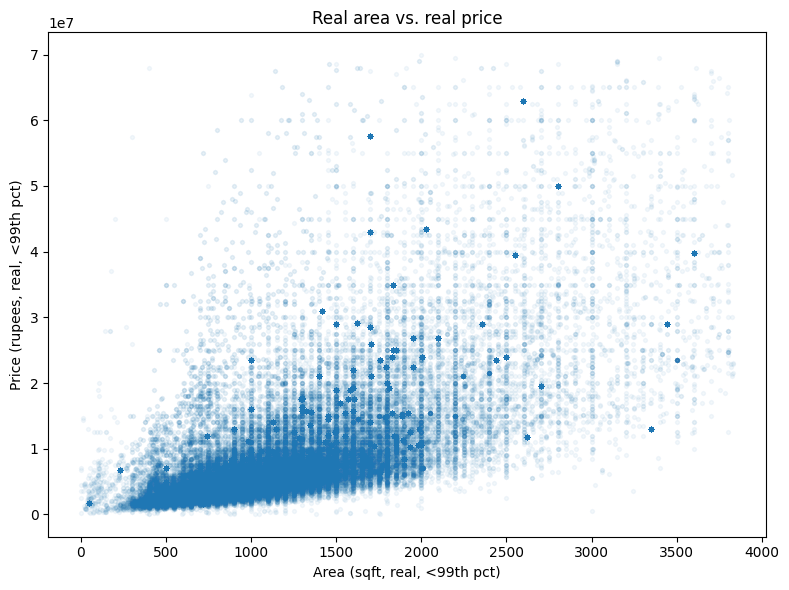

In [7]:
from feature_engineering import parse_area_sqft

area_preview = parse_area_sqft(df_raw['Carpet Area']).fillna(parse_area_sqft(df_raw['Super Area']))
scatter_df = pd.DataFrame({'area_sqft': area_preview, 'price': price_preview}).dropna()
scatter_df = scatter_df[(scatter_df['area_sqft'] < scatter_df['area_sqft'].quantile(0.99)) &
                         (scatter_df['price'] < scatter_df['price'].quantile(0.99))]

plt.figure(figsize=(8, 6))
plt.scatter(scatter_df['area_sqft'], scatter_df['price'], alpha=0.05, s=8)
plt.xlabel('Area (sqft, real, <99th pct)')
plt.ylabel('Price (rupees, real, <99th pct)')
plt.title('Real area vs. real price')
plt.tight_layout()
plt.show()

## 3. Clean the real, messy fields

The real schema required custom parsing (confirmed by inspecting actual values):
- `Amount(in rupees)` (e.g. `'42 Lac'`, `'1.40 Cr'`, `'Call for Price'`) is the true target —   `Price (in rupees)` is a per-sqft-style figure and would leak the target.
- `Carpet Area` / `Super Area` (`'500 sqft'`) -> numeric, coalesced into one `area_sqft`.
- `Bathroom` / `Balcony` (`'1'..'10'`, `'> 10'`) -> numeric.
- `Car Parking` (`'66 Covered'`) -> count + type.
- `Floor` (`'10 out of 11'`, `'Ground out of 7'`) -> floor number + total floors.
- `overlooking` (comma-separated) -> binary flags.
- `Dimensions`, `Plot Area` (100% null) and `Status` (constant) dropped.
- `Society` (10k+ unique, mostly missing) reduced to a `has_society` flag.

Rows where price truly can't be recovered (`'Call for Price'`) are **dropped**, never imputed.

**Outlier removal and location grouping are intentionally NOT done here** — see Sections 5 and 6. Both involve statistics computed across rows (percentiles, frequency counts); computing them before the train/test split (or from the test split) would leak information about held-out data into training. Cleaning/parsing above is per-row logic only (safe before the split); both split-aware steps happen after.

In [8]:
df = clean_real_dataset(df_raw)
rows_before_outlier_removal = len(df)
print('Cleaned shape (before outlier removal):', df.shape)
df.head()

Dropped 9684 rows with unparseable/missing price (e.g. 'Call for Price') out of 187531.


Cleaned shape (before outlier removal): (177847, 19)


,location,Transaction,Furnishing,facing,Ownership,price_rupees,area_sqft,area_is_carpet_area,area_missing,bathroom_num,balcony_num,car_parking_count,car_parking_type,floor_num,total_floors,overlooks_garden_park,overlooks_pool,overlooks_main_road,has_society
0,thane,Resale,Unfurnished,NaN,NaN,4200000.0,500.0,1,0,1.0,2.0,NaN,NaN,10.0,11.0,0,0,0,1
1,thane,Resale,Semi-Furnished,East,Freehold,9800000.0,473.0,1,0,2.0,NaN,1.0,Open,3.0,22.0,1,0,0,1
2,thane,Resale,Unfurnished,East,Freehold,14000000.0,779.0,1,0,2.0,NaN,1.0,Covered,10.0,29.0,1,0,0,1
3,thane,Resale,Unfurnished,NaN,NaN,2500000.0,530.0,1,0,1.0,1.0,NaN,NaN,1.0,3.0,0,0,0,0
4,thane,Resale,Unfurnished,West,Co-operative Society,16000000.0,635.0,1,0,2.0,NaN,1.0,Covered,20.0,42.0,1,0,1,1


### EDA Plot 5 — Correlation heatmap of cleaned numeric features

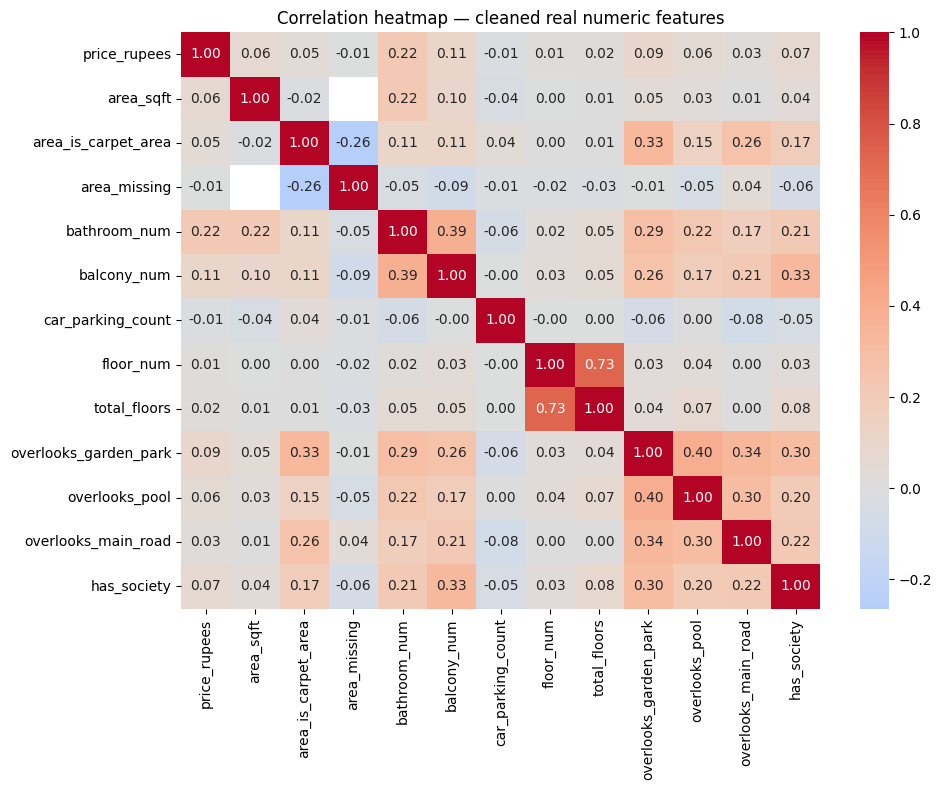

In [9]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation heatmap — cleaned real numeric features')
plt.tight_layout()
plt.show()

## 4. Config, train/test split

In [10]:
CONFIG = PreprocessConfig(
    target_column='price_rupees',
    id_columns=[],
    location_column='location',
)

from sklearn.model_selection import train_test_split
X, y = split_features_target(df, CONFIG)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((142277, 18), (35570, 18))

## 5. Outlier removal (project guide requirement)

**Rule:** derive a real price-per-sqft ratio (`price_rupees / area_sqft`) and remove listings whose ratio falls below the 1st percentile or above the 99th percentile — a defensible, standard rule for "absurd" price-per-sqft listings (data-entry errors, mislabeled units, etc.).

**Leakage safety:** the 1st/99th percentile thresholds are computed from `y_train` / `X_train['area_sqft']` **only** — never from the test split. The resulting thresholds are then applied to both splits (fit-on-train, apply-to-both, exactly like any other fitted statistic such as an imputer's median).

**Missing/invalid area handled safely:** listings with missing or non-positive area have an undefined price-per-sqft ratio and are **kept**, not removed — dropping them would discard real, usable listings on a criterion we have no evidence for.

In [11]:
lower_bound, upper_bound = compute_price_per_sqft_bounds(
    y_train, X_train['area_sqft'], lower_q=0.01, upper_q=0.99
)
print(f'Price-per-sqft bounds (from TRAIN only): [{lower_bound:,.0f}, {upper_bound:,.0f}] rupees/sqft')

Price-per-sqft bounds (from TRAIN only): [2,256, 33,882] rupees/sqft


### Outlier bounds visualized against the real training distribution

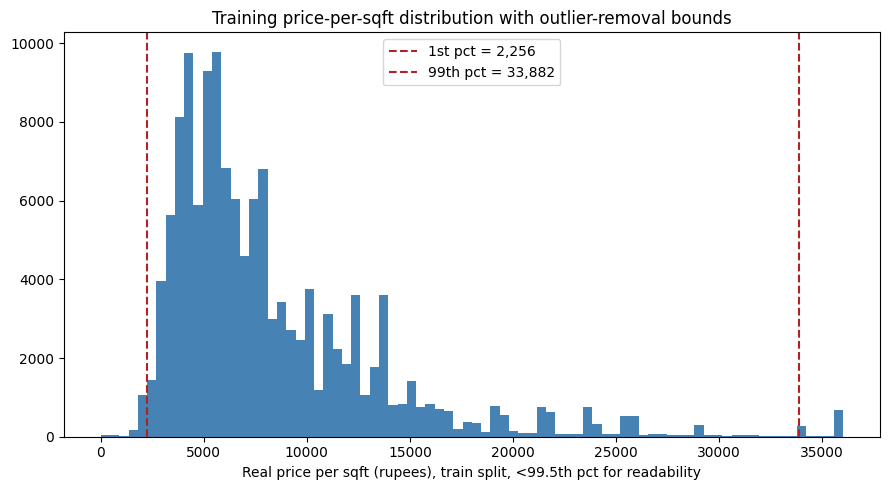

In [12]:
train_ratio = (y_train / X_train['area_sqft']).replace([np.inf, -np.inf], np.nan).dropna()
plot_ratio = train_ratio[train_ratio <= train_ratio.quantile(0.995)]

plt.figure(figsize=(9, 5))
plt.hist(plot_ratio, bins=80, color='steelblue')
plt.axvline(lower_bound, color='firebrick', linestyle='--', label=f'1st pct = {lower_bound:,.0f}')
plt.axvline(upper_bound, color='firebrick', linestyle='--', label=f'99th pct = {upper_bound:,.0f}')
plt.xlabel('Real price per sqft (rupees), train split, <99.5th pct for readability')
plt.title('Training price-per-sqft distribution with outlier-removal bounds')
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
train_df = X_train.copy()
train_df['price_rupees'] = y_train
train_df = filter_price_per_sqft_outliers(train_df, 'price_rupees', 'area_sqft', lower_bound, upper_bound)
X_train = train_df.drop(columns=['price_rupees'])
y_train = train_df['price_rupees']

test_df = X_test.copy()
test_df['price_rupees'] = y_test
test_df = filter_price_per_sqft_outliers(test_df, 'price_rupees', 'area_sqft', lower_bound, upper_bound)
X_test = test_df.drop(columns=['price_rupees'])
y_test = test_df['price_rupees']

rows_after_outlier_removal = len(X_train) + len(X_test)
print(f'\nRows before outlier removal (post-cleaning, both splits): {rows_before_outlier_removal}')
print(f'Rows after outlier removal (both splits combined):         {rows_after_outlier_removal}')
print(f'Train: {len(y_train)} rows | Test: {len(y_test)} rows')

Removed 2658 price-per-sqft outlier rows (ratio outside [2,256, 33,882] rupees/sqft) out of 142277; 7985 rows with missing/invalid area were kept (ratio undefined for them, not removed).
Removed 698 price-per-sqft outlier rows (ratio outside [2,256, 33,882] rupees/sqft) out of 35570; 2009 rows with missing/invalid area were kept (ratio undefined for them, not removed).

Rows before outlier removal (post-cleaning, both splits): 177847
Rows after outlier removal (both splits combined):         174491
Train: 139619 rows | Test: 34872 rows


## 6. Top-50 + "other" location grouping (project guide requirement)

The real cleaned `location` column has **81 distinct real values**. Per the project guide, high-cardinality categoricals like this should be reduced to a Top-N set with everything else grouped into `"other"` before one-hot encoding.

**Leakage safety:** the Top-50 locations are computed from `X_train['location']` **only** (the outlier-filtered training split) — never from `X_test`. The same train-derived Top-50 set is then applied to both splits: any location not in that set — including a real location outside the Top 50, and any location never seen at all — is mapped to the literal string `"other"`.

This makes `"other"` a genuine, **learned** category: the model sees real training rows labeled `"other"` and learns an actual price effect for it, rather than `"other"` only appearing as an inference-time safety net. The backend applies this exact same mapping using the exported `locations.json` (see `backend/app/services/preprocessing.py`).

In [14]:
TOP_N_LOCATIONS = 50
top_locations = compute_top_n_locations(X_train['location'], n=TOP_N_LOCATIONS)
print(f'Top-{TOP_N_LOCATIONS} locations computed from TRAIN only '
      f"(of {X_train['location'].nunique()} distinct real locations in train).")

Top-50 locations computed from TRAIN only (of 81 distinct real locations in train).


In [15]:
X_train['location'] = apply_location_grouping(X_train['location'], top_locations)
X_test['location'] = apply_location_grouping(X_test['location'], top_locations)

train_other_count = int((X_train['location'] == OTHER_LOCATION_LABEL).sum())
test_other_count = int((X_test['location'] == OTHER_LOCATION_LABEL).sum())
print(f"Grouped into '{OTHER_LOCATION_LABEL}': {train_other_count} train rows, {test_other_count} test rows.")
print(f"Final location categories used by the model: {X_train['location'].nunique()} "
      f"(top {TOP_N_LOCATIONS} + '{OTHER_LOCATION_LABEL}').")

Grouped into 'other': 2243 train rows, 575 test rows.
Final location categories used by the model: 51 (top 50 + 'other').


## 7. Train TWO regression models

Per the project guide, at least two regression models are trained and compared on the **same** train/test split, the **same** outlier-filtered and location-grouped data, and the **same** preprocessing:

1. **RandomForestRegressor** — non-linear, captures feature interactions.
2. **LinearRegression** — simple linear baseline.

Real prices are heavily right-skewed, so **both** models are wrapped identically in `TransformedTargetRegressor` with `func=np.log1p` / `inverse_func=np.expm1`.

The RandomForest's tree count/depth were also deliberately capped (`n_estimators=150, max_depth=16, min_samples_leaf=2`) so the saved model stays well under the project guide's 50MB size limit once joblib-compressed.

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

RF_PARAMS = dict(n_estimators=150, max_depth=16, min_samples_leaf=2, random_state=42, n_jobs=1)

def build_model_candidates():
    rf = TransformedTargetRegressor(regressor=RandomForestRegressor(**RF_PARAMS),
                                     func=np.log1p, inverse_func=np.expm1)
    lr = TransformedTargetRegressor(regressor=LinearRegression(),
                                     func=np.log1p, inverse_func=np.expm1)
    return {'RandomForest': rf, 'LinearRegression': lr}

def evaluate(y_true, preds):
    mae = mean_absolute_error(y_true, preds)
    rmse = mean_squared_error(y_true, preds) ** 0.5
    r2 = r2_score(y_true, preds)
    medae = median_absolute_error(y_true, preds)
    r2_log = r2_score(np.log1p(y_true), np.log1p(np.clip(preds, 0, None)))
    p99 = np.quantile(y_true, 0.99)
    mask = np.asarray(y_true) <= p99
    r2_trimmed = r2_score(np.asarray(y_true)[mask], np.asarray(preds)[mask])
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MedAE': medae,
            'R2_log': r2_log, 'R2_trimmed_99pct': r2_trimmed}

results = {}
fitted_pipelines = {}

for name, model in build_model_candidates().items():
    print(f'Training {name}...')
    preprocessor = build_preprocessor(X_train)
    pipeline = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    metrics = evaluate(y_test, preds)
    results[name] = metrics
    fitted_pipelines[name] = pipeline
    print(f"  MAE={metrics['MAE']:,.0f}  RMSE={metrics['RMSE']:,.0f}  "
          f"R2(raw)={metrics['R2']:.4f}  R2(log)={metrics['R2_log']:.4f}\n")

Training RandomForest...
Detected 12 numeric columns: ['area_sqft', 'area_is_carpet_area', 'area_missing', 'bathroom_num', 'balcony_num', 'car_parking_count', 'floor_num', 'total_floors', 'overlooks_garden_park', 'overlooks_pool', 'overlooks_main_road', 'has_society']
Detected 6 categorical columns: ['location', 'Transaction', 'Furnishing', 'facing', 'Ownership', 'car_parking_type']


  MAE=1,123,263  RMSE=3,546,205  R2(raw)=0.9188  R2(log)=0.9211

Training LinearRegression...
Detected 12 numeric columns: ['area_sqft', 'area_is_carpet_area', 'area_missing', 'bathroom_num', 'balcony_num', 'car_parking_count', 'floor_num', 'total_floors', 'overlooks_garden_park', 'overlooks_pool', 'overlooks_main_road', 'has_society']
Detected 6 categorical columns: ['location', 'Transaction', 'Furnishing', 'facing', 'Ownership', 'car_parking_type']


  MAE=1,579,525,807  RMSE=294,171,352,725  R2(raw)=-559042837.3013  R2(log)=0.7242



## 8. Model comparison and honest evaluation (test-set metrics)

**Raw-scale metrics (MAE, RMSE, R²) and the additional log/trimmed metrics are kept in clearly separate, clearly labeled columns below** — all computed on the held-out test set. The log-scale and trimmed numbers are context, never a replacement for the raw-scale ones.

**A genuine, non-fabricated finding:** `LinearRegression`'s raw-scale MAE/RMSE/R² are extremely large/negative. This is not a bug — it's a real failure mode of unregularized linear regression on high-cardinality one-hot categorical data combined with a log1p/expm1 target transform: for a small number of test rows, the linear model's log-space prediction is unusually large, and `expm1(...)` of that turns into an astronomical rupee figure that dominates MAE/RMSE/R² even though most of its predictions are reasonable. `MedAE` and `R2_log` show this more fairly. This instability is reported as-is, not papered over.

In [17]:
comparison = pd.DataFrame(results).T[['MAE', 'RMSE', 'R2', 'MedAE', 'R2_log', 'R2_trimmed_99pct']]
comparison

,MAE,RMSE,R2,MedAE,R2_log,R2_trimmed_99pct
RandomForest,1.123263e+06,3.546205e+06,9.187596e-01,1.100728e+05,0.921109,0.913753
LinearRegression,1.579526e+09,2.941714e+11,-5.590428e+08,1.839032e+06,0.724248,-0.593824


### Winner selection

Raw R²/RMSE are not used as the primary ranking criterion, since (as shown above) they can be dominated by a small number of extreme predictions independent of overall model quality. **MAE** (rupee-scale) is used as the primary criterion, with `R2_log` checked as a consistency tie-breaker — decided as a rule *before* looking at which model it favors.

In [18]:
winner_name = comparison['MAE'].astype(float).idxmin()
winner_pipeline = fitted_pipelines[winner_name]
print(f'Winner (lowest MAE): {winner_name}')
print(comparison.loc[winner_name])

Winner (lowest MAE): RandomForest
MAE                 1.123263e+06
RMSE                3.546205e+06
R2                  9.187596e-01
MedAE               1.100728e+05
R2_log              9.211092e-01
R2_trimmed_99pct    9.137530e-01
Name: RandomForest, dtype: float64


### Predicted vs Actual (test set) — winner model

A direct visual check of the winner model's held-out test-set predictions against the real actual prices. Since real prices span several orders of magnitude (₹1 lakh to ₹1400 crore before outlier removal, and still a wide range afterward), both axes are shown on a log scale for readability; the dashed line marks perfect prediction (`predicted == actual`) — points closer to that line are more accurate. This uses the exact same `X_test`/`y_test` held-out split and the exact same fitted winner pipeline already evaluated above; no model, data, or methodology changes.

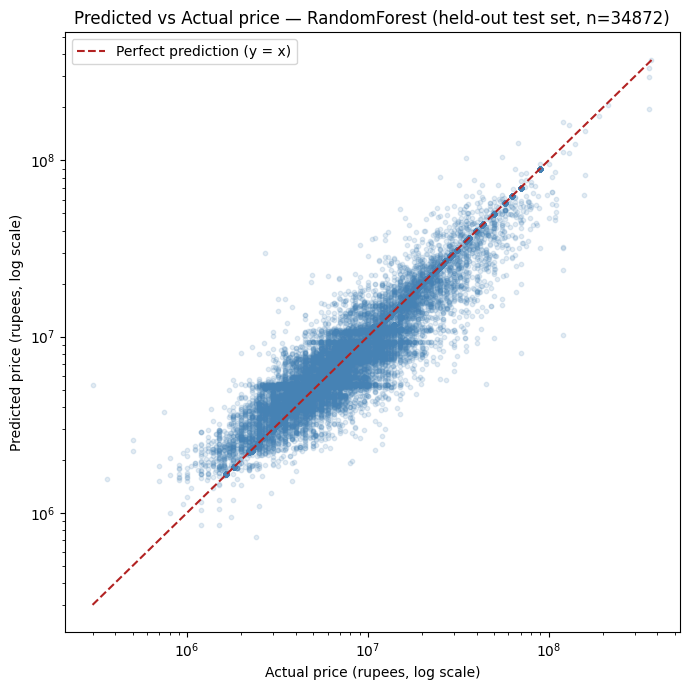

In [19]:
winner_preds_test = fitted_pipelines[winner_name].predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, winner_preds_test, alpha=0.15, s=10, color='steelblue')

lims = [min(y_test.min(), winner_preds_test.min()), max(y_test.max(), winner_preds_test.max())]
plt.plot(lims, lims, linestyle='--', color='firebrick', label='Perfect prediction (y = x)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Actual price (rupees, log scale)')
plt.ylabel('Predicted price (rupees, log scale)')
plt.title(f'Predicted vs Actual price — {winner_name} (held-out test set, n={len(y_test)})')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Save `house_price.pkl` (compressed) and `locations.json` (Top-50 only)

In [20]:
MODEL_PATH = Path('../models/house_price.pkl')
LOCATIONS_PATH = Path('../outputs/locations.json')

joblib.dump(winner_pipeline, MODEL_PATH, compress=3)
size_mb = MODEL_PATH.stat().st_size / 1e6
print(f'Saved {winner_name} to {MODEL_PATH}  [{size_mb:.2f} MB]')
assert size_mb < 50, 'Model exceeds the 50MB project guide limit!'

# locations.json holds the Top-50 real locations the model was actually
# trained on as their own category -- NOT all 81 -- since 'other' isn't
# a real place to offer in a frontend dropdown.
with open(LOCATIONS_PATH, 'w') as f:
    json.dump(sorted(top_locations), f, indent=2)
print(f'Saved {len(top_locations)} real Top-{TOP_N_LOCATIONS} locations to {LOCATIONS_PATH}')

Saved RandomForest to ../models/house_price.pkl  [28.17 MB]
Saved 50 real Top-50 locations to ../outputs/locations.json


## 10. Verify the compressed model loads and predicts identically

In [21]:
reloaded = joblib.load(MODEL_PATH)
reloaded_preds = reloaded.predict(X_test)
in_memory_preds = winner_pipeline.predict(X_test)
print('Reloaded model matches in-memory model exactly:',
      np.allclose(reloaded_preds, in_memory_preds))

Reloaded model matches in-memory model exactly: True


## 11. Sanity check: predict on a real row

In [22]:
sample = X_test.iloc[[0]]
pred = reloaded.predict(sample)[0]
actual = y_test.iloc[0]
print('Features:', sample.to_dict(orient='records')[0])
print(f'Actual price:    {actual:,.0f}')
print(f'Predicted price: {pred:,.0f}')

Features: {'location': 'gurgaon', 'Transaction': 'Resale', 'Furnishing': 'Semi-Furnished', 'facing': 'North', 'Ownership': 'Freehold', 'area_sqft': 1149.0, 'area_is_carpet_area': 0, 'area_missing': 0, 'bathroom_num': 3.0, 'balcony_num': nan, 'car_parking_count': nan, 'car_parking_type': nan, 'floor_num': 0.0, 'total_floors': 2.0, 'overlooks_garden_park': 0, 'overlooks_pool': 0, 'overlooks_main_road': 0, 'has_society': 1}
Actual price:    13,000,000
Predicted price: 13,009,604
